# Student Placement Analytics & Prediction
## Phase 1 — Exploratory Data Analysis + Model Training
**Dataset:** Campus Recruitment — Factors Affecting Campus Placement (Kaggle — benroshan)  
**Rows:** 215 | **Features:** 13 | **Target:** `status` (Placed / Not Placed)  
**File:** `Placement_Data_Full_Class.csv`

---
## Cell 1 — Imports & Setup

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
import joblib
import json
import os

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

PLACED_COLOR   = '#6BAF92'
UNPLACED_COLOR = '#E07B7B'

print('All libraries loaded!')

All libraries loaded!


---
## Cell 2 — Load & Inspect Dataset

In [17]:
df = pd.read_csv('../data/Placement_Data_Full_Class.csv')

# Drop serial number — not a feature
df.drop(columns=['sl_no'], inplace=True)

print(f'Shape: {df.shape}  ({df.shape[0]} rows, {df.shape[1]} columns)')
print('\nColumn names:', df.columns.tolist())
print('\nTarget distribution:')
vc = df['status'].value_counts()
for k, v in vc.items():
    print(f'  {k}: {v} ({v/len(df)*100:.1f}%)')
df.head()

Shape: (215, 14)  (215 rows, 14 columns)

Column names: ['gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'status', 'salary']

Target distribution:
  Placed: 148 (68.8%)
  Not Placed: 67 (31.2%)


,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


---
## Cell 3 — Column Reference & Missing Values

In [18]:
col_desc = {
    'gender':         'Gender (M/F)',
    'ssc_p':          '10th (SSC) percentage',
    'ssc_b':          '10th board (Central/Others)',
    'hsc_p':          '12th (HSC) percentage',
    'hsc_b':          '12th board (Central/Others)',
    'hsc_s':          '12th specialisation (Science/Commerce/Arts)',
    'degree_p':       'Degree percentage',
    'degree_t':       'Degree field (Sci&Tech / Comm&Mgmt / Others)',
    'workex':         'Work experience (Yes/No)',
    'etest_p':        'Employability test percentage',
    'specialisation': 'MBA specialisation (Mkt&HR / Mkt&Fin)',
    'mba_p':          'MBA percentage',
    'status':         'TARGET — Placed / Not Placed',
    'salary':         'Salary offered (only if placed)'
}
print('=== Column Descriptions ===')
for col, desc in col_desc.items():
    if col in df.columns:
        print(f'  {col:15s}: {desc}')

print('\n=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values!')

print('\n=== Data Types ===')
print(df.dtypes)

=== Column Descriptions ===
  gender         : Gender (M/F)
  ssc_p          : 10th (SSC) percentage
  ssc_b          : 10th board (Central/Others)
  hsc_p          : 12th (HSC) percentage
  hsc_b          : 12th board (Central/Others)
  hsc_s          : 12th specialisation (Science/Commerce/Arts)
  degree_p       : Degree percentage
  degree_t       : Degree field (Sci&Tech / Comm&Mgmt / Others)
  workex         : Work experience (Yes/No)
  etest_p        : Employability test percentage
  specialisation : MBA specialisation (Mkt&HR / Mkt&Fin)
  mba_p          : MBA percentage
  status         : TARGET — Placed / Not Placed
  salary         : Salary offered (only if placed)

=== Missing Values ===
salary    67
dtype: int64

=== Data Types ===
gender             object
ssc_p             float64
ssc_b              object
hsc_p             float64
hsc_b              object
hsc_s              object
degree_p          float64
degree_t           object
workex             object
etest_p      

---
## Cell 4 — EDA: Placement Rate Overview

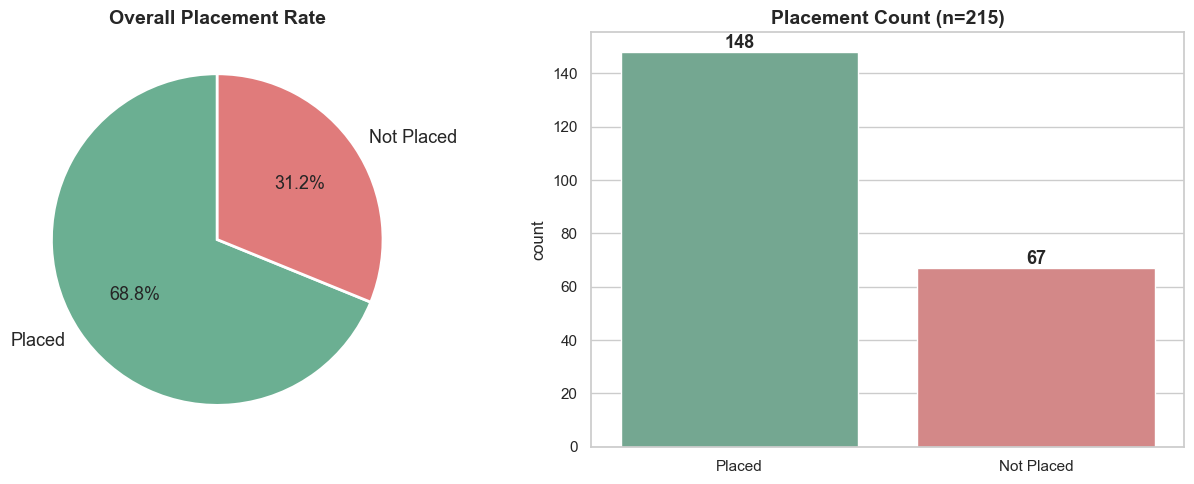

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df['status'].value_counts()
axes[0].pie(
    counts, labels=counts.index,
    colors=[PLACED_COLOR, UNPLACED_COLOR],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 13},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Overall Placement Rate', fontsize=14, fontweight='bold')

sns.countplot(
    x='status', data=df,
    palette={'Placed': PLACED_COLOR, 'Not Placed': UNPLACED_COLOR},
    order=['Placed', 'Not Placed'], ax=axes[1]
)
axes[1].set_title(f'Placement Count (n={len(df)})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/plot_01_placement_dist.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 5 — EDA: Academic Scores vs Placement

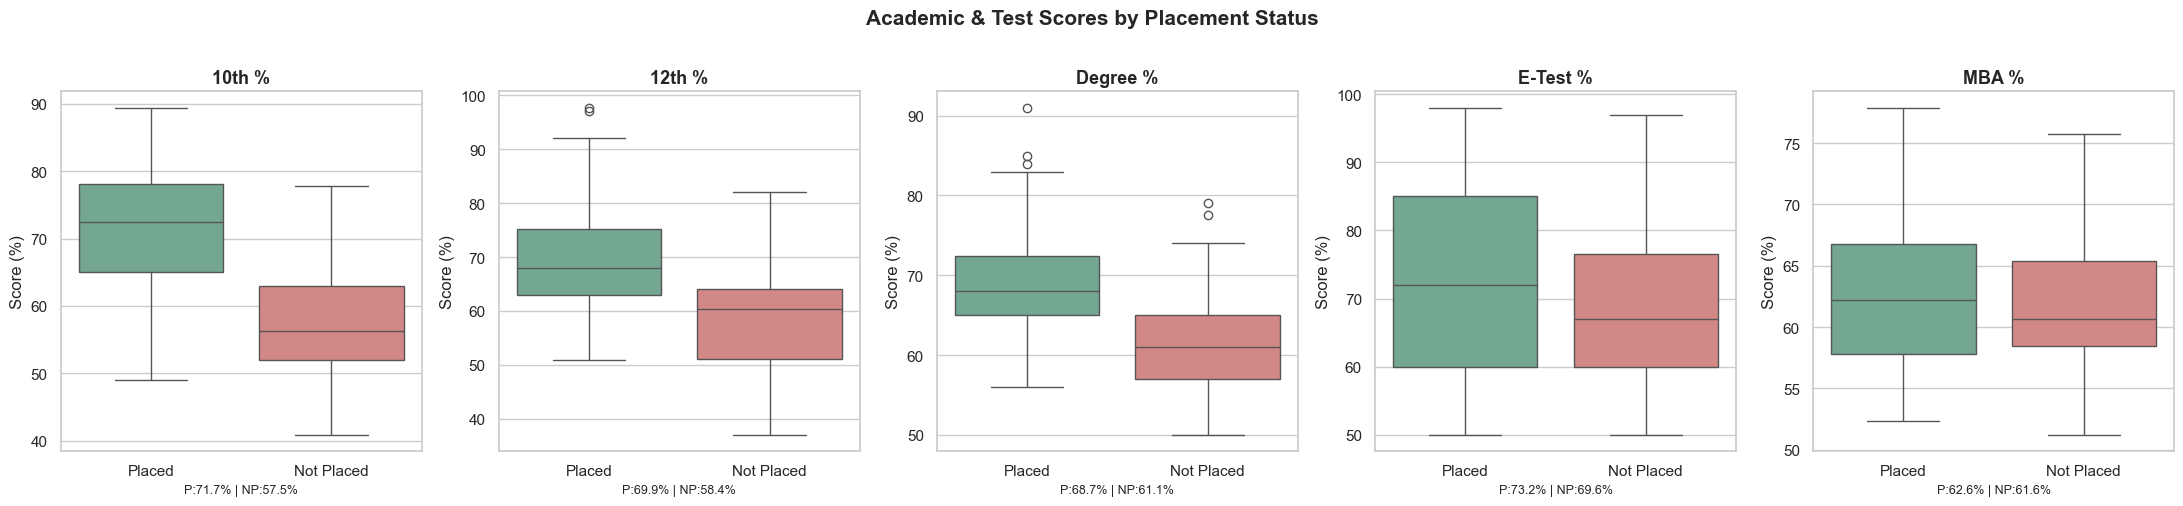

In [20]:
score_cols  = ['ssc_p',    'hsc_p',    'degree_p', 'etest_p', 'mba_p']
score_labels = ['10th %', '12th %', 'Degree %', 'E-Test %', 'MBA %']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, col, label in zip(axes, score_cols, score_labels):
    sns.boxplot(
        x='status', y=col, data=df,
        palette={'Placed': PLACED_COLOR, 'Not Placed': UNPLACED_COLOR},
        order=['Placed', 'Not Placed'], ax=ax
    )
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Score (%)')
    means = df.groupby('status')[col].mean()
    placed_mean = means.get('Placed', 0)
    np_mean     = means.get('Not Placed', 0)
    ax.set_xlabel(f'P:{placed_mean:.1f}% | NP:{np_mean:.1f}%', fontsize=9)

plt.suptitle('Academic & Test Scores by Placement Status', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/plot_02_scores.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 6 — EDA: Gender & Work Experience vs Placement

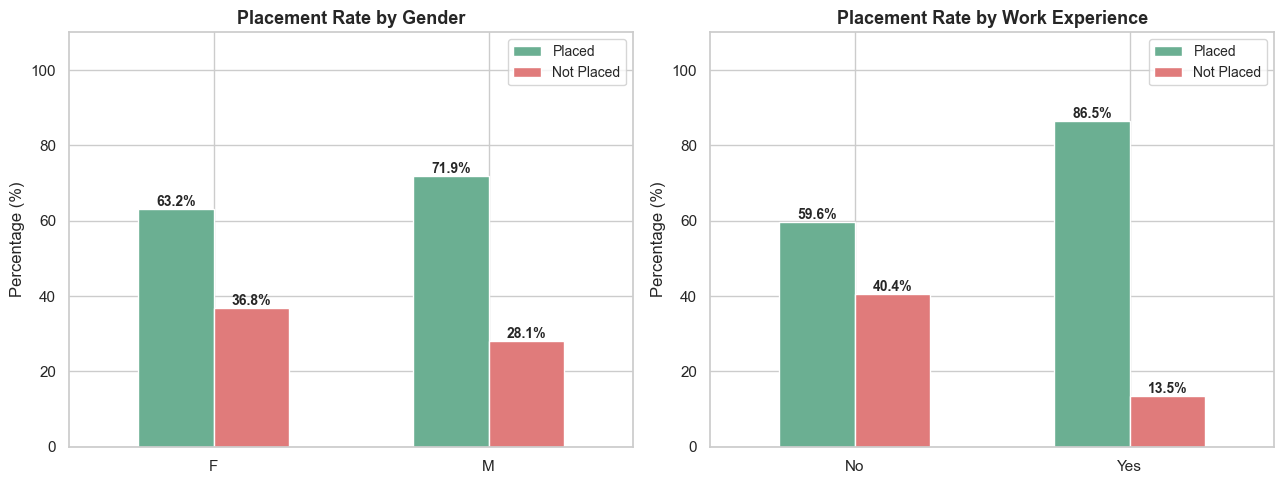

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in zip(
    axes,
    ['gender', 'workex'],
    ['Placement Rate by Gender', 'Placement Rate by Work Experience']
):
    ct = pd.crosstab(df[col], df['status'], normalize='index') * 100
    ct = ct[['Placed', 'Not Placed']] if 'Placed' in ct.columns else ct
    ct.plot(kind='bar', ax=ax,
            color=[PLACED_COLOR, UNPLACED_COLOR],
            edgecolor='white', width=0.55)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=10)
    ax.set_ylim(0, 110)
    for bar in ax.patches:
        ax.annotate(f'{bar.get_height():.1f}%',
                    (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/plot_03_gender_workex.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 7 — EDA: Stream & Specialisation vs Placement

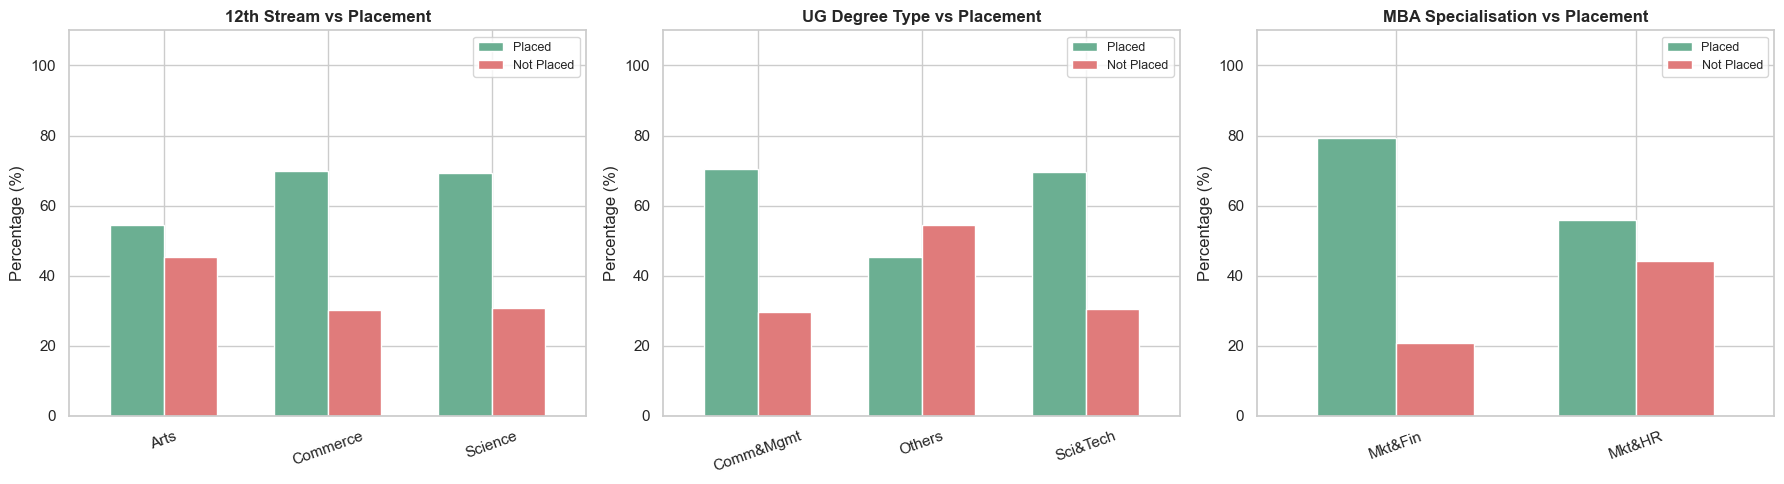

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(
    axes,
    ['hsc_s', 'degree_t', 'specialisation'],
    ['12th Stream vs Placement', 'UG Degree Type vs Placement', 'MBA Specialisation vs Placement']
):
    ct = pd.crosstab(df[col], df['status'], normalize='index') * 100
    ct = ct[['Placed', 'Not Placed']] if 'Placed' in ct.columns else ct
    ct.plot(kind='bar', ax=ax,
            color=[PLACED_COLOR, UNPLACED_COLOR],
            edgecolor='white', width=0.65)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig('../data/plot_04_streams.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 8 — EDA: Salary Analysis (Placed Students)

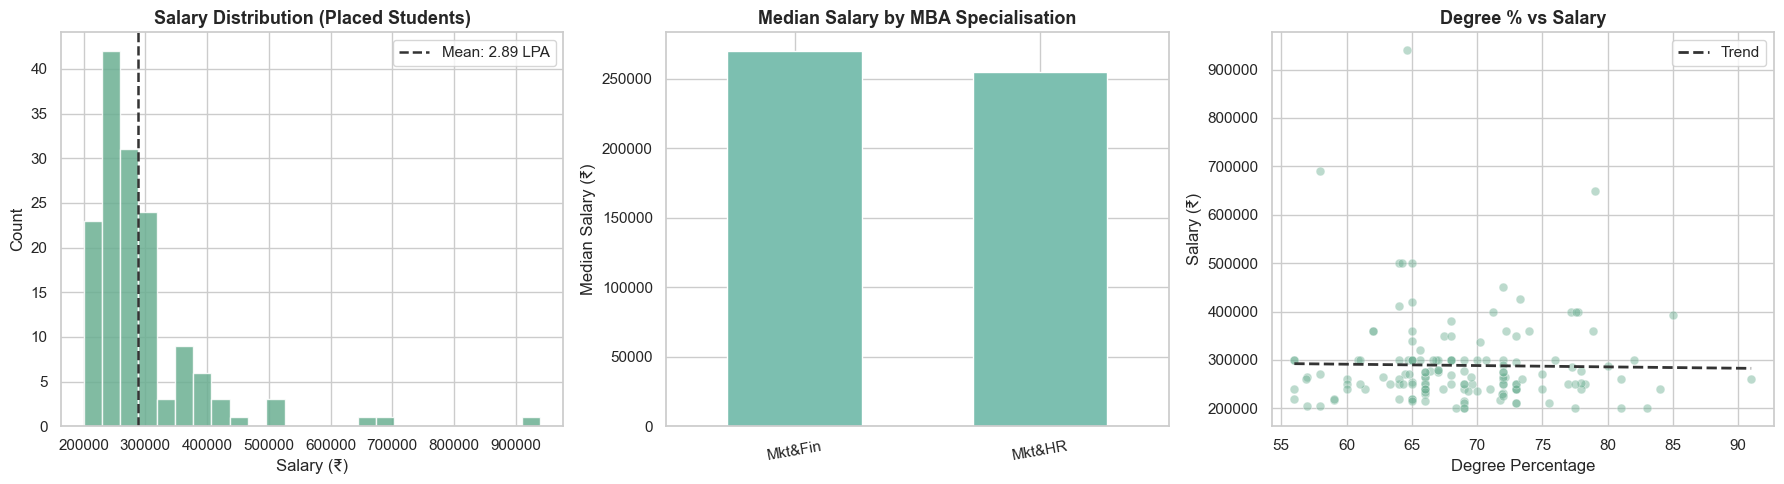

Salary stats (Placed students):
count        148
mean     288,655
std       93,457
min      200,000
25%      240,000
50%      265,000
75%      300,000
max      940,000
Name: salary, dtype: object


In [23]:
placed_df = df[df['status'] == 'Placed'].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Salary distribution
axes[0].hist(placed_df['salary'], bins=25,
             color=PLACED_COLOR, edgecolor='white', alpha=0.85)
axes[0].axvline(placed_df['salary'].mean(), color='#333',
                linestyle='--', linewidth=1.8,
                label=f"Mean: {placed_df['salary'].mean()/100000:.2f} LPA")
axes[0].set_title('Salary Distribution (Placed Students)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Salary (₹)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Salary by MBA specialisation
sal_spec = placed_df.groupby('specialisation')['salary'].median().sort_values(ascending=False)
sal_spec.plot(kind='bar', ax=axes[1], color='#7CBFB0', edgecolor='white', width=0.55)
axes[1].set_title('Median Salary by MBA Specialisation', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Median Salary (₹)')
axes[1].tick_params(axis='x', rotation=10)

# Degree % vs Salary
axes[2].scatter(placed_df['degree_p'], placed_df['salary'],
                alpha=0.45, color=PLACED_COLOR, s=40, edgecolors='white', linewidth=0.5)
z = np.polyfit(placed_df['degree_p'], placed_df['salary'], 1)
p = np.poly1d(z)
x_line = np.linspace(placed_df['degree_p'].min(), placed_df['degree_p'].max(), 100)
axes[2].plot(x_line, p(x_line), color='#333', linewidth=2, linestyle='--', label='Trend')
axes[2].set_title('Degree % vs Salary', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Degree Percentage')
axes[2].set_ylabel('Salary (₹)')
axes[2].legend()

plt.tight_layout()
plt.savefig('../data/plot_05_salary.png', dpi=150, bbox_inches='tight')
plt.show()

print('Salary stats (Placed students):')
print(placed_df['salary'].describe().apply(lambda x: f'{x:,.0f}'))

---
## Cell 9 — Correlation Heatmap

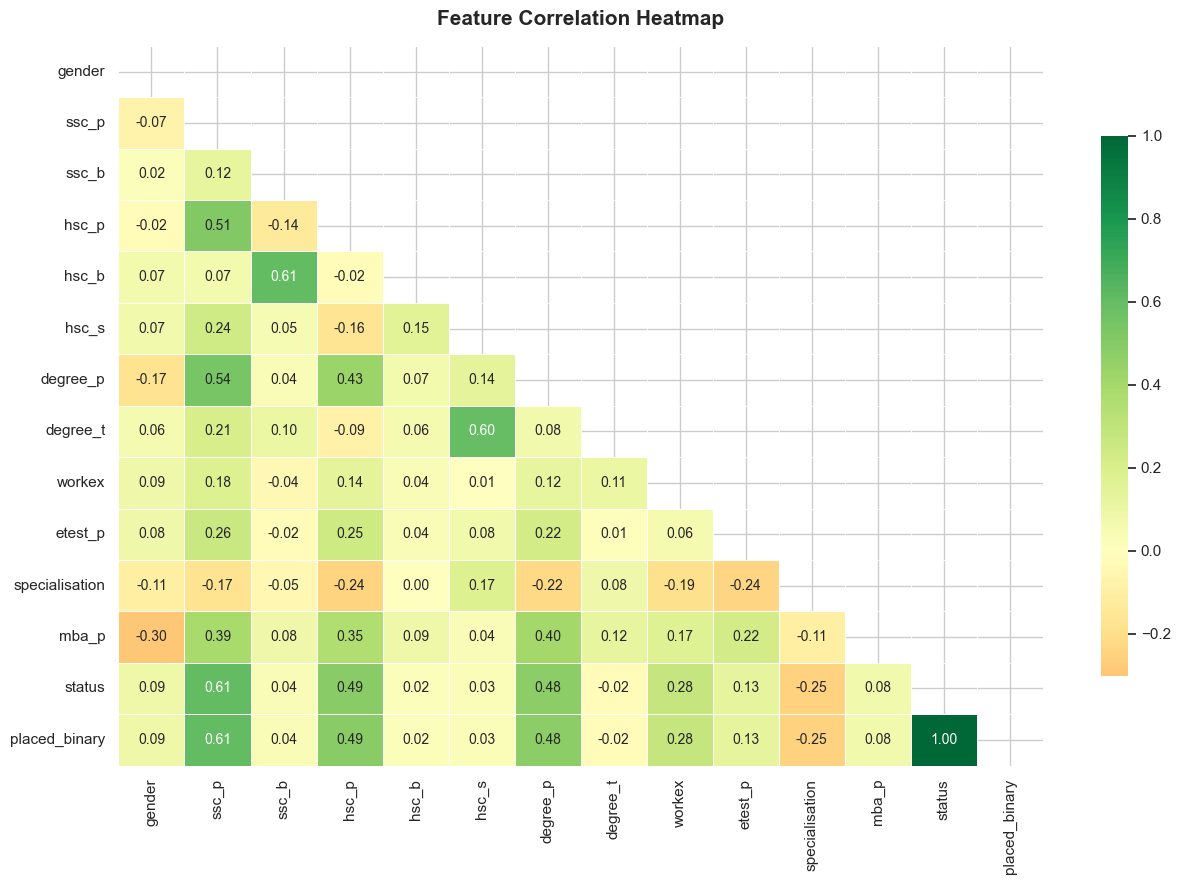

Top correlations with placement status:
status            1.000
ssc_p             0.608
hsc_p             0.491
degree_p          0.480
workex            0.276
etest_p           0.128
gender            0.091
mba_p             0.077
ssc_b             0.037
hsc_s             0.033
hsc_b             0.017
degree_t         -0.020
specialisation   -0.251
Name: placed_binary, dtype: float64


In [24]:
df_corr = df.copy()
df_corr['placed_binary'] = (df_corr['status'] == 'Placed').astype(int)

# Encode categoricals temporarily for correlation
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

# Exclude salary (only available post-placement)
numeric_cols = [c for c in df_corr.select_dtypes(include=np.number).columns
                if c != 'salary']

plt.figure(figsize=(13, 9))
corr = df_corr[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    annot_kws={'size': 10}, cbar_kws={'shrink': 0.75}
)
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/plot_06_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top correlations with placement status:')
print(corr['placed_binary'].drop('placed_binary').sort_values(ascending=False).round(3))

---
## Cell 10 — Preprocessing

In [25]:
df_model = df.copy()

# Drop salary — data leakage (only known after placement)
df_model.drop(columns=['salary'], inplace=True)

# Encode target
df_model['status'] = (df_model['status'] == 'Placed').astype(int)

# Encode all categorical columns
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
le_dict = {}
print('Label encoding:')
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    print(f'  {col:16s}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

X = df_model.drop(columns=['status'])
y = df_model['status']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]} | Features: {len(feature_names)}')

Label encoding:
  gender          : {'F': 0, 'M': 1}
  ssc_b           : {'Central': 0, 'Others': 1}
  hsc_b           : {'Central': 0, 'Others': 1}
  hsc_s           : {'Arts': 0, 'Commerce': 1, 'Science': 2}
  degree_t        : {'Comm&Mgmt': 0, 'Others': 1, 'Sci&Tech': 2}
  workex          : {'No': 0, 'Yes': 1}
  specialisation  : {'Mkt&Fin': 0, 'Mkt&HR': 1}

Train: 172 | Test: 43 | Features: 12


---
## Cell 11 — Train & Compare Models

In [26]:
models = {
    'Random Forest':       (RandomForestClassifier(n_estimators=200, random_state=42), False),
    'Gradient Boosting':   (GradientBoostingClassifier(n_estimators=150, random_state=42), False),
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), True),
    'SVM':                 (SVC(probability=True, random_state=42), True),
}

results = {}
print(f'{"Model":<25}  {"Accuracy":>10}  {"ROC-AUC":>10}  {"CV (5-fold)":>12}')
print('-' * 65)
for name, (model, use_scaled) in models.items():
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc  if use_scaled else X_test
    Xfull = scaler.transform(X) if use_scaled else X

    model.fit(Xtr, y_train)
    y_pred  = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    cv  = cross_val_score(model, Xfull, y, cv=5, scoring='accuracy').mean()

    results[name] = {
        'model': model, 'acc': acc, 'auc': auc, 'cv': cv,
        'y_pred': y_pred, 'y_proba': y_proba, 'scaled': use_scaled
    }
    print(f'{name:<25}  {acc*100:>9.2f}%  {auc:>10.4f}  {cv*100:>10.2f}%')

best_name = max(results, key=lambda k: results[k]['acc'])
print(f'\nBest model: {best_name}  ({results[best_name]["acc"]*100:.2f}% accuracy)')

Model                        Accuracy     ROC-AUC   CV (5-fold)
-----------------------------------------------------------------
Random Forest                  83.72%      0.9308       86.98%
Gradient Boosting              81.40%      0.9256       82.33%
Logistic Regression            83.72%      0.9308       84.65%
SVM                            88.37%      0.9051       86.98%

Best model: SVM  (88.37% accuracy)


---
## Cell 12 — Confusion Matrix & ROC Curve

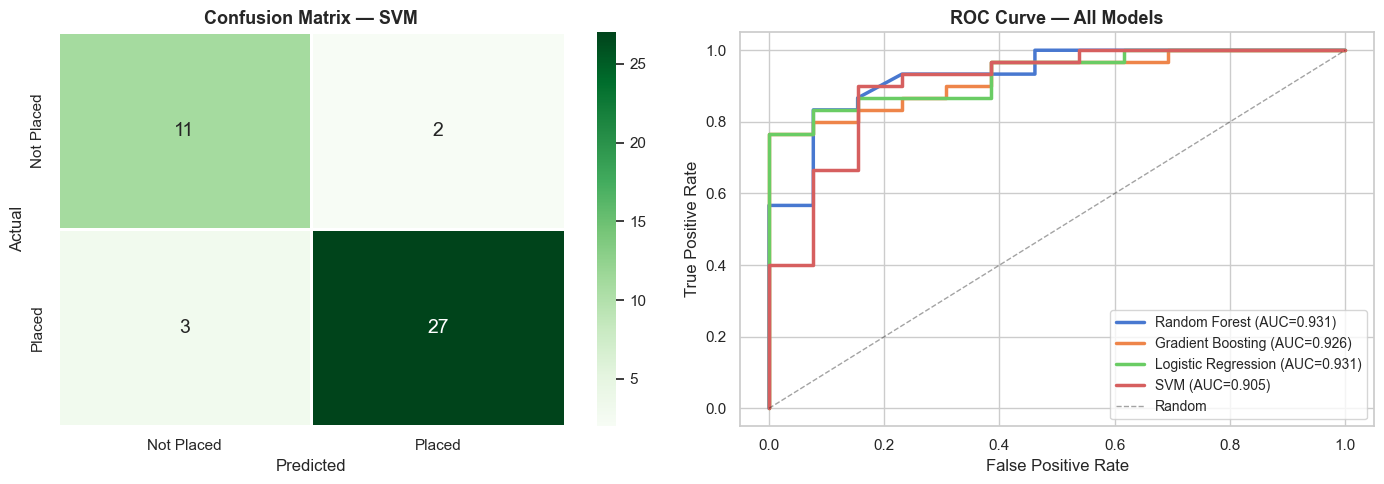


Classification Report — SVM:
              precision    recall  f1-score   support

  Not Placed       0.79      0.85      0.81        13
      Placed       0.93      0.90      0.92        30

    accuracy                           0.88        43
   macro avg       0.86      0.87      0.87        43
weighted avg       0.89      0.88      0.88        43



In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, results[best_name]['y_pred'])
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Not Placed', 'Placed'],
    yticklabels=['Not Placed', 'Placed'],
    linewidths=1, ax=axes[0], annot_kws={'size': 14}
)
axes[0].set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[1].plot(fpr, tpr, linewidth=2.5,
                 label=f"{name} (AUC={res['auc']:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.4, label='Random')
axes[1].set_title('ROC Curve — All Models', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('../data/plot_07_model_eval.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nClassification Report — {best_name}:')
print(classification_report(
    y_test, results[best_name]['y_pred'],
    target_names=['Not Placed', 'Placed']
))

---
## Cell 13 — Feature Importance

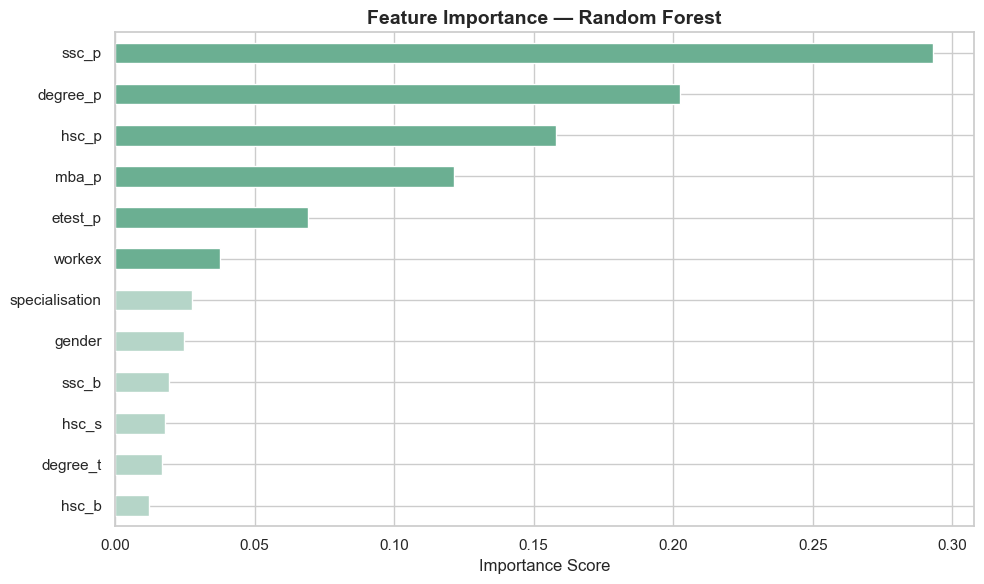

Top features:
ssc_p             0.2931
degree_p          0.2023
hsc_p             0.1581
mba_p             0.1215
etest_p           0.0692
workex            0.0375
specialisation    0.0276
gender            0.0249
ssc_b             0.0192
hsc_s             0.0177
degree_t          0.0166
hsc_b             0.0122
dtype: float64


In [28]:
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=True)

colors = ['#6BAF92' if v >= importances.median() else '#B5D5C8' for v in importances]

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/plot_08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top features:')
print(importances.sort_values(ascending=False).round(4))

---
## Cell 14 — Save All Artifacts

In [29]:
os.makedirs('../app', exist_ok=True)

best_model = results[best_name]['model']

joblib.dump(best_model,    '../app/model.pkl')
joblib.dump(scaler,        '../app/scaler.pkl')
joblib.dump(feature_names, '../app/feature_names.pkl')
joblib.dump(le_dict,       '../app/label_encoders.pkl')

cat_mappings = {col: le.classes_.tolist() for col, le in le_dict.items()}

metadata = {
    'best_model':   best_name,
    'accuracy':     round(results[best_name]['acc'], 4),
    'roc_auc':      round(results[best_name]['auc'], 4),
    'cv_accuracy':  round(results[best_name]['cv'], 4),
    'features':     feature_names,
    'cat_mappings': cat_mappings,
    'target':       'status',
    'train_size':   int(X_train.shape[0]),
    'test_size':    int(X_test.shape[0]),
    'dataset':      'Campus Recruitment — benroshan (Kaggle)'
}
with open('../app/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved to ../app/:')
print('  model.pkl')
print('  scaler.pkl')
print('  feature_names.pkl')
print('  label_encoders.pkl')
print('  model_metadata.json')
print(f'\nBest model  : {best_name}')
print(f'Accuracy    : {metadata["accuracy"]*100:.2f}%')
print(f'ROC-AUC     : {metadata["roc_auc"]:.4f}')
print(f'CV Accuracy : {metadata["cv_accuracy"]*100:.2f}%')

Saved to ../app/:
  model.pkl
  scaler.pkl
  feature_names.pkl
  label_encoders.pkl
  model_metadata.json

Best model  : SVM
Accuracy    : 88.37%
ROC-AUC     : 0.9051
CV Accuracy : 86.98%
